### B3: Technical Indicator + Fundamnetal indicator + sector + transcript sentiment

In [22]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

In [23]:
# ── Tech modeling table ───────────────────────────────────────────────────
tech_path = "../../data/model_staging/tech_modeling_table.parquet"
df_tech   = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")

# ── Fundamental features ──────────────────────────────────────────────────
fund_path = "../../data/model_staging/modeling_fundamentals.parquet"
df_fund   = pl.read_parquet(fund_path)

df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq",
    "revenue_growth_qoq",
    "gross_margin",     "gross_margin_qoq",
    "debt_to_equity",   "debt_to_equity_qoq",
    "fcf_margin",       "fcf_margin_qoq",
    "roe",              "roe_qoq",
])

# ── FinBERT transcript sentiment ──────────────────────────────────────────
df_finbert = pl.read_parquet("../../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "pos_prob",
    "neg_prob",
])
print(f"FinBERT shape: {df_finbert.shape}")

# ── Merge onto tech table ─────────────────────────────────────────────────
df_model = df_tech.join(df_fund,    on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")

print(f"Combined table shape: {df_model.shape}")
print(f"Target: {df_model['target_class']} positive")
print(f"\nNull counts for sentiment cols:")
print(df_model.select(["pos_prob", "neg_prob"]).null_count())

Tech table shape: (23094, 241)
FinBERT shape: (24294, 4)
Combined table shape: (23094, 253)
Target: shape: (23_094,)
Series: 'target_class' [i64]
[
	1
	2
	2
	0
	0
	…
	2
	0
	1
	1
	0
] positive

Null counts for sentiment cols:
shape: (1, 2)
┌──────────┬──────────┐
│ pos_prob ┆ neg_prob │
│ ---      ┆ ---      │
│ u32      ┆ u32      │
╞══════════╪══════════╡
│ 0        ┆ 0        │
└──────────┴──────────┘


In [24]:
print(df_model.select(["pos_prob", "neg_prob"]))

shape: (23_094, 2)
┌──────────┬──────────┐
│ pos_prob ┆ neg_prob │
│ ---      ┆ ---      │
│ f64      ┆ f64      │
╞══════════╪══════════╡
│ 0.423797 ┆ 0.551445 │
│ 0.38163  ┆ 0.410867 │
│ 0.484371 ┆ 0.431905 │
│ 0.521163 ┆ 0.438704 │
│ 0.575968 ┆ 0.376174 │
│ …        ┆ …        │
│ 0.527995 ┆ 0.436667 │
│ 0.373317 ┆ 0.511039 │
│ 0.512283 ┆ 0.281072 │
│ 0.407182 ┆ 0.326112 │
│ 0.420953 ┆ 0.341021 │
└──────────┴──────────┘


In [25]:
# Source sector from FinBERT parquet (has symbol → sector mapping)
df_sector_raw = pl.read_parquet("../../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector     = df_sector_raw.select(["symbol", "sector"]).unique()

df_sector = df_sector.with_columns(
    pl.col("sector").fill_null("Unknown")
)

sectors   = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")

print(f"Sectors: {sectors}")
print(f"Unique symbols in sector map: {df_sector.shape[0]}")

df_model = df_model.join(df_sector, on="symbol", how="left")

sector_cols = [c for c in df_model.columns if c.startswith("sector_")]
print(f"Shape after sector join: {df_model.shape}")
print(f"Sector columns: {sector_cols}")

Sectors: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']
Unique symbols in sector map: 503
Shape after sector join: (23094, 265)
Sector columns: ['sector_Basic_Materials', 'sector_Communication_Services', 'sector_Consumer_Cyclical', 'sector_Consumer_Defensive', 'sector_Energy', 'sector_Financial_Services', 'sector_Healthcare', 'sector_Industrials', 'sector_Real_Estate', 'sector_Technology', 'sector_Unknown', 'sector_Utilities']


In [26]:
# ── Add year/quarter for expanding-window folds ──────────────
df_model = df_model.with_columns([
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.quarter().alias("quarter"),
])
df_model = df_model.filter(pl.col("year") <= 2025)

INITIAL_TRAIN_YEARS = 7
EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_class", "max_high", "min_high", "max_day", "min_day",
    "car_3day", "car_t2_t10",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]
print(f"Total features: {len(feature_cols)}")

unique_quarters = df_model.select(["year", "quarter"]).unique().sort(["year", "quarter"])
quarters_list = unique_quarters.to_dicts()

earliest_year = quarters_list[0]["year"]
initial_train_end_year = earliest_year + INITIAL_TRAIN_YEARS - 1
first_test_idx = next(i for i, q in enumerate(quarters_list) if q["year"] > initial_train_end_year)

print(f"Initial training: {earliest_year}–{initial_train_end_year} ({INITIAL_TRAIN_YEARS} yrs)")
print(f"First test: {quarters_list[first_test_idx]}")

folds_data = []
fold_num = 1

for test_quarter_idx in range(first_test_idx, len(quarters_list)):
    test_q = quarters_list[test_quarter_idx]
    val_q  = quarters_list[test_quarter_idx - 1]
    test_label = f"{test_q['year']}_Q{test_q['quarter']}"

    test_data = df_model.filter(
        (pl.col("year") == test_q["year"]) & (pl.col("quarter") == test_q["quarter"])
    )
    train_data = df_model.filter(
        (pl.col("year") < val_q["year"]) |
        ((pl.col("year") == val_q["year"]) & (pl.col("quarter") < val_q["quarter"]))
    )

    if len(train_data) == 0 or len(test_data) == 0:
        continue

    X_train = train_data.select(feature_cols).to_numpy()
    X_test  = test_data.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    folds_data.append({
        "fold_num":    fold_num,
        "test_quarter": test_label,
        "test_year":   test_q["year"],
        "X_train":     X_train,    "X_test":     X_test,
        "X_train_sc":  X_train_sc, "X_test_sc":  X_test_sc,
        "y_train_cls": train_data["target_class"].to_numpy(),
        "y_test_cls":  test_data["target_class"].to_numpy(),
        "y_train_ret": train_data["target_return"].to_numpy(),
        "y_test_ret":  test_data["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num:2d} [{test_label}]:  "
          f"train={X_train.shape[0]:6,}  "
          f"test={X_test.shape[0]:4,}")

    fold_num += 1

print(f"\nTotal folds: {len(folds_data)}")

# For fold-across-year comparison charts
fold_years = [f["test_year"] for f in folds_data]


Total features: 258
Initial training: 2014–2020 (7 yrs)
First test: {'year': 2021, 'quarter': 1}
Fold  1 [2021_Q1]:  train=12,683  test= 492
Fold  2 [2021_Q2]:  train=13,169  test= 493
Fold  3 [2021_Q3]:  train=13,661  test= 493
Fold  4 [2021_Q4]:  train=14,154  test= 492
Fold  5 [2022_Q1]:  train=14,647  test= 494
Fold  6 [2022_Q2]:  train=15,139  test= 495
Fold  7 [2022_Q3]:  train=15,633  test= 493
Fold  8 [2022_Q4]:  train=16,128  test= 493
Fold  9 [2023_Q1]:  train=16,621  test= 492
Fold 10 [2023_Q2]:  train=17,114  test= 498
Fold 11 [2023_Q3]:  train=17,606  test= 496
Fold 12 [2023_Q4]:  train=18,104  test= 498
Fold 13 [2024_Q1]:  train=18,600  test= 496
Fold 14 [2024_Q2]:  train=19,098  test= 501
Fold 15 [2024_Q3]:  train=19,594  test= 499
Fold 16 [2024_Q4]:  train=20,095  test= 504
Fold 17 [2025_Q1]:  train=20,594  test= 502
Fold 18 [2025_Q2]:  train=21,098  test= 501
Fold 19 [2025_Q3]:  train=21,600  test= 502
Fold 20 [2025_Q4]:  train=22,101  test= 491

Total folds: 20


In [27]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_dir = np.random.randint(0, 3, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_dir)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_dir)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nAvg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.3455
Fold 2: DA=0.3185
Fold 3: DA=0.3144
Fold 4: DA=0.3252
Fold 5: DA=0.3563
Fold 6: DA=0.3535
Fold 7: DA=0.3225
Fold 8: DA=0.3469
Fold 9: DA=0.3476
Fold 10: DA=0.3253
Fold 11: DA=0.3085
Fold 12: DA=0.3112
Fold 13: DA=0.3468
Fold 14: DA=0.3573
Fold 15: DA=0.3287
Fold 16: DA=0.3075
Fold 17: DA=0.3048
Fold 18: DA=0.3533
Fold 19: DA=0.3665
Fold 20: DA=0.3564

Avg DA:   0.3348
Avg MAE:  0.0306
Avg RMSE: 0.0450


In [28]:
lr_clf   = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])

    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

print(f"\nAvg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(np.array(lr_clf['true']), np.array(lr_clf['preds']), average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(np.array(lr_clf['true']), np.array(lr_clf['probs']), multi_class='ovr'):.4f}")

Fold 1 [2021_Q1]: DA=0.8415
Fold 2 [2021_Q2]: DA=0.8093
Fold 3 [2021_Q3]: DA=0.7809
Fold 4 [2021_Q4]: DA=0.8008
Fold 5 [2022_Q1]: DA=0.8360
Fold 6 [2022_Q2]: DA=0.7616
Fold 7 [2022_Q3]: DA=0.8682
Fold 8 [2022_Q4]: DA=0.8783
Fold 9 [2023_Q1]: DA=0.7866
Fold 10 [2023_Q2]: DA=0.8233
Fold 11 [2023_Q3]: DA=0.7802
Fold 12 [2023_Q4]: DA=0.8514
Fold 13 [2024_Q1]: DA=0.8085
Fold 14 [2024_Q2]: DA=0.8323
Fold 15 [2024_Q3]: DA=0.7776
Fold 16 [2024_Q4]: DA=0.8095
Fold 17 [2025_Q1]: DA=0.7649
Fold 18 [2025_Q2]: DA=0.8623
Fold 19 [2025_Q3]: DA=0.7809
Fold 20 [2025_Q4]: DA=0.7902

Avg DA:     0.8122
Pooled F1:  0.8152
Pooled AUC: 0.9379


In [29]:
linreg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
linreg_model = LinearRegression()

for f in folds_data:
    linreg_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = linreg_model.predict(f["X_test_sc"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    linreg["fold_mae"].append(mae)
    linreg["fold_rmse"].append(rmse)
    linreg["preds"].extend(preds)
    linreg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(linreg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(linreg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(linreg['true']), np.array(linreg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0145  RMSE=0.0209
Fold 2 [2021_Q2]: MAE=0.0106  RMSE=0.0140
Fold 3 [2021_Q3]: MAE=0.0106  RMSE=0.0140
Fold 4 [2021_Q4]: MAE=0.0115  RMSE=0.0161
Fold 5 [2022_Q1]: MAE=0.0152  RMSE=0.0221
Fold 6 [2022_Q2]: MAE=0.0165  RMSE=0.0230
Fold 7 [2022_Q3]: MAE=0.0128  RMSE=0.0172
Fold 8 [2022_Q4]: MAE=0.0151  RMSE=0.0225
Fold 9 [2023_Q1]: MAE=0.0107  RMSE=0.0165
Fold 10 [2023_Q2]: MAE=0.0101  RMSE=0.0149
Fold 11 [2023_Q3]: MAE=0.0099  RMSE=0.0155
Fold 12 [2023_Q4]: MAE=0.0105  RMSE=0.0144
Fold 13 [2024_Q1]: MAE=0.0088  RMSE=0.0148
Fold 14 [2024_Q2]: MAE=0.0100  RMSE=0.0158
Fold 15 [2024_Q3]: MAE=0.0142  RMSE=0.0249
Fold 16 [2024_Q4]: MAE=0.0132  RMSE=0.0263
Fold 17 [2025_Q1]: MAE=0.0123  RMSE=0.0196
Fold 18 [2025_Q2]: MAE=0.0152  RMSE=0.0278
Fold 19 [2025_Q3]: MAE=0.0125  RMSE=0.0214
Fold 20 [2025_Q4]: MAE=0.0120  RMSE=0.0157

Avg MAE:   0.0123
Avg RMSE:  0.0189
Pooled R²: 0.8204


In [30]:
rf_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(
    n_estimators=50, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])

    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

print(f"\nAvg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(np.array(rf_clf['true']), np.array(rf_clf['preds']), average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(np.array(rf_clf['true']), np.array(rf_clf['probs']), multi_class='ovr'):.4f}")

Fold 1 [2021_Q1]: DA=0.8557
Fold 2 [2021_Q2]: DA=0.7931
Fold 3 [2021_Q3]: DA=0.8296
Fold 4 [2021_Q4]: DA=0.7947
Fold 5 [2022_Q1]: DA=0.8340
Fold 6 [2022_Q2]: DA=0.7515
Fold 7 [2022_Q3]: DA=0.8540
Fold 8 [2022_Q4]: DA=0.8661
Fold 9 [2023_Q1]: DA=0.7947
Fold 10 [2023_Q2]: DA=0.8253
Fold 11 [2023_Q3]: DA=0.8024
Fold 12 [2023_Q4]: DA=0.8614
Fold 13 [2024_Q1]: DA=0.8327
Fold 14 [2024_Q2]: DA=0.8224
Fold 15 [2024_Q3]: DA=0.7695
Fold 16 [2024_Q4]: DA=0.8056
Fold 17 [2025_Q1]: DA=0.7510
Fold 18 [2025_Q2]: DA=0.8463
Fold 19 [2025_Q3]: DA=0.8108
Fold 20 [2025_Q4]: DA=0.7800

Avg DA:     0.8140
Pooled F1:  0.8117
Pooled AUC: 0.9305


In [31]:
rf_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
rf_reg_model = XGBRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0101  RMSE=0.0157
Fold 2 [2021_Q2]: MAE=0.0073  RMSE=0.0097
Fold 3 [2021_Q3]: MAE=0.0065  RMSE=0.0102
Fold 4 [2021_Q4]: MAE=0.0072  RMSE=0.0104
Fold 5 [2022_Q1]: MAE=0.0094  RMSE=0.0159
Fold 6 [2022_Q2]: MAE=0.0105  RMSE=0.0148
Fold 7 [2022_Q3]: MAE=0.0084  RMSE=0.0121
Fold 8 [2022_Q4]: MAE=0.0116  RMSE=0.0174
Fold 9 [2023_Q1]: MAE=0.0082  RMSE=0.0127
Fold 10 [2023_Q2]: MAE=0.0075  RMSE=0.0155
Fold 11 [2023_Q3]: MAE=0.0065  RMSE=0.0092
Fold 12 [2023_Q4]: MAE=0.0082  RMSE=0.0129
Fold 13 [2024_Q1]: MAE=0.0064  RMSE=0.0097
Fold 14 [2024_Q2]: MAE=0.0071  RMSE=0.0123
Fold 15 [2024_Q3]: MAE=0.0101  RMSE=0.0166
Fold 16 [2024_Q4]: MAE=0.0092  RMSE=0.0272
Fold 17 [2025_Q1]: MAE=0.0085  RMSE=0.0136
Fold 18 [2025_Q2]: MAE=0.0107  RMSE=0.0197
Fold 19 [2025_Q3]: MAE=0.0080  RMSE=0.0153
Fold 20 [2025_Q4]: MAE=0.0079  RMSE=0.0114

Avg MAE:   0.0085
Avg RMSE:  0.0141
Pooled R²: 0.8962


In [32]:
xgb_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])

    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

print(f"\nAvg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(np.array(xgb_clf['true']), np.array(xgb_clf['preds']), average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(np.array(xgb_clf['true']), np.array(xgb_clf['probs']), multi_class='ovr'):.4f}")

Fold 1 [2021_Q1]: DA=0.8801
Fold 2 [2021_Q2]: DA=0.8215
Fold 3 [2021_Q3]: DA=0.8519
Fold 4 [2021_Q4]: DA=0.8313
Fold 5 [2022_Q1]: DA=0.8502
Fold 6 [2022_Q2]: DA=0.7758
Fold 7 [2022_Q3]: DA=0.8763
Fold 8 [2022_Q4]: DA=0.8884
Fold 9 [2023_Q1]: DA=0.8394
Fold 10 [2023_Q2]: DA=0.8253
Fold 11 [2023_Q3]: DA=0.8306
Fold 12 [2023_Q4]: DA=0.8614
Fold 13 [2024_Q1]: DA=0.8548
Fold 14 [2024_Q2]: DA=0.8383
Fold 15 [2024_Q3]: DA=0.7976
Fold 16 [2024_Q4]: DA=0.8194
Fold 17 [2025_Q1]: DA=0.8127
Fold 18 [2025_Q2]: DA=0.8862
Fold 19 [2025_Q3]: DA=0.8526
Fold 20 [2025_Q4]: DA=0.8147

Avg DA:     0.8404
Pooled F1:  0.8399
Pooled AUC: 0.9509


In [33]:
xgb_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(n_estimators=200, random_state=42)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0102  RMSE=0.0158
Fold 2 [2021_Q2]: MAE=0.0075  RMSE=0.0101
Fold 3 [2021_Q3]: MAE=0.0069  RMSE=0.0104
Fold 4 [2021_Q4]: MAE=0.0075  RMSE=0.0106
Fold 5 [2022_Q1]: MAE=0.0098  RMSE=0.0161
Fold 6 [2022_Q2]: MAE=0.0110  RMSE=0.0152
Fold 7 [2022_Q3]: MAE=0.0087  RMSE=0.0125
Fold 8 [2022_Q4]: MAE=0.0115  RMSE=0.0174
Fold 9 [2023_Q1]: MAE=0.0085  RMSE=0.0129
Fold 10 [2023_Q2]: MAE=0.0077  RMSE=0.0156
Fold 11 [2023_Q3]: MAE=0.0068  RMSE=0.0099
Fold 12 [2023_Q4]: MAE=0.0084  RMSE=0.0132
Fold 13 [2024_Q1]: MAE=0.0067  RMSE=0.0101
Fold 14 [2024_Q2]: MAE=0.0074  RMSE=0.0124
Fold 15 [2024_Q3]: MAE=0.0104  RMSE=0.0167
Fold 16 [2024_Q4]: MAE=0.0094  RMSE=0.0274
Fold 17 [2025_Q1]: MAE=0.0089  RMSE=0.0140
Fold 18 [2025_Q2]: MAE=0.0112  RMSE=0.0201
Fold 19 [2025_Q3]: MAE=0.0085  RMSE=0.0161
Fold 20 [2025_Q4]: MAE=0.0081  RMSE=0.0115

Avg MAE:   0.0088
Avg RMSE:  0.0144
Pooled R²: 0.8925


In [34]:
print("=== Direction (Classification) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Prec':>8} {'Recall':>8} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf), ("XGBoost", xgb_clf)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1   = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec  = recall_score(true, preds, average="weighted")
    auc_str = (f"{roc_auc_score(true, np.array(r['probs']), multi_class='ovr', average='weighted'):>8.4f}"
               if r.get("probs") else f"{'—':>8}")
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>8.4f} {rec:>8.4f} {auc_str}")

print(f"\n=== Magnitude (Regression) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Linear Regression", linreg),
                ("Random Forest", rf_reg), ("XGBoost", xgb_reg)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} "
          f"{np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Direction (Classification) ===
Model                        Avg DA%  Pooled F1     Prec   Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.3348     0.3395   0.3563   0.3348        —
Logistic Regression           0.8122     0.8152   0.8201   0.8122   0.9454
Random Forest                 0.8140     0.8117   0.8158   0.8140   0.9385
XGBoost                       0.8404     0.8399   0.8423   0.8404   0.9566

=== Magnitude (Regression) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0306     0.0450    -0.0189
Linear Regression             0.0123     0.0189     0.8204
Random Forest                 0.0085     0.0141     0.8962
XGBoost                       0.0088     0.0144     0.8925


In [35]:
model_dir = Path.cwd().parent / "model_outputs" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

for name, model in [("lr_clf",  lr_model),
                    ("linreg",  linreg_model),
                    ("rf_clf",  rf_clf_model),
                    ("rf_reg",  rf_reg_model),
                    ("xgb_clf", xgb_clf_model),
                    ("xgb_reg", xgb_reg_model)]:
    joblib.dump(model, model_dir / f"b3_{name}.pkl")
    print(f"Saved {model_dir / f'b3_{name}.pkl'}")

with open(model_dir / "b3_results.pkl", "wb") as f:
    pickle.dump({
        "clf": {"B0 Random":          b0_clf,
                "Logistic Regression": lr_clf,
                "Random Forest":       rf_clf,
                "XGBoost":             xgb_clf},
        "reg": {"B0 Mean":            b0_reg,
                "Linear Regression":   linreg,
                "Random Forest":       rf_reg,
                "XGBoost":             xgb_reg},
    }, f)
print(f"Saved {model_dir / 'b3_results.pkl'}")

Saved /Users/ahelidas/Library/Mobile Documents/com~apple~CloudDocs/MBAI Stuffs/Capstone Project/Post-Earnings-Forecast/src/modeling/model_outputs/models/b3_lr_clf.pkl
Saved /Users/ahelidas/Library/Mobile Documents/com~apple~CloudDocs/MBAI Stuffs/Capstone Project/Post-Earnings-Forecast/src/modeling/model_outputs/models/b3_linreg.pkl
Saved /Users/ahelidas/Library/Mobile Documents/com~apple~CloudDocs/MBAI Stuffs/Capstone Project/Post-Earnings-Forecast/src/modeling/model_outputs/models/b3_rf_clf.pkl
Saved /Users/ahelidas/Library/Mobile Documents/com~apple~CloudDocs/MBAI Stuffs/Capstone Project/Post-Earnings-Forecast/src/modeling/model_outputs/models/b3_rf_reg.pkl
Saved /Users/ahelidas/Library/Mobile Documents/com~apple~CloudDocs/MBAI Stuffs/Capstone Project/Post-Earnings-Forecast/src/modeling/model_outputs/models/b3_xgb_clf.pkl
Saved /Users/ahelidas/Library/Mobile Documents/com~apple~CloudDocs/MBAI Stuffs/Capstone Project/Post-Earnings-Forecast/src/modeling/model_outputs/models/b3_xgb_reg.

In [36]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['grid.color']       = 'gray'

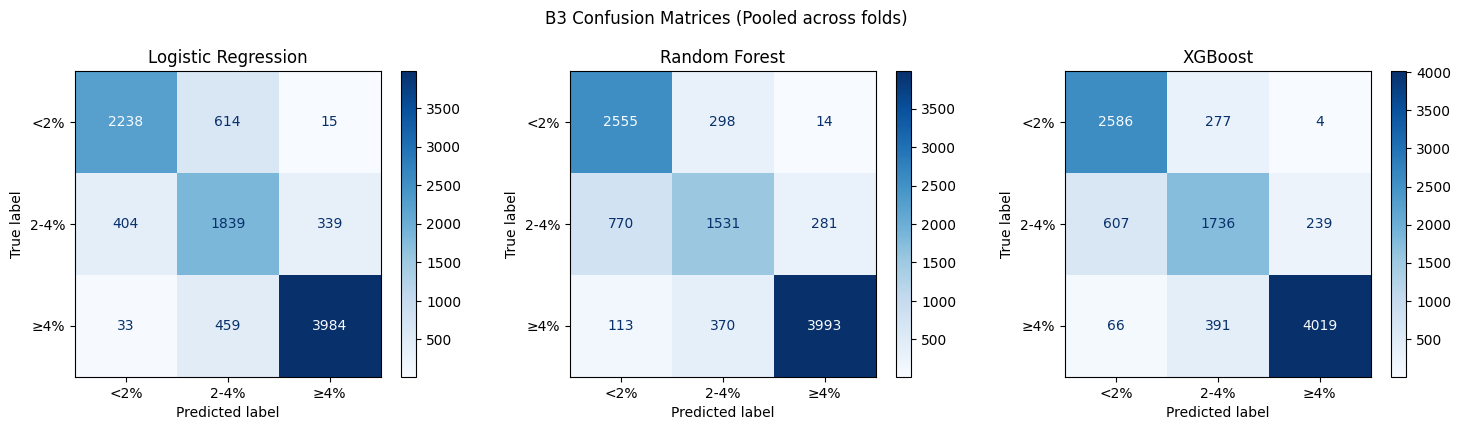

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Logistic Regression", lr_clf),
                                  ("Random Forest",       rf_clf),
                                  ("XGBoost",             xgb_clf)]):
    ConfusionMatrixDisplay.from_predictions(
        np.array(r["true"]), np.array(r["preds"]),
        ax=ax, cmap="Blues", display_labels=["<2%", "2-4%", "≥4%"],
    )
    ax.set_title(name)

plt.suptitle("B3 Confusion Matrices (Pooled across folds)", y=1.02)
plt.tight_layout()
plt.show()

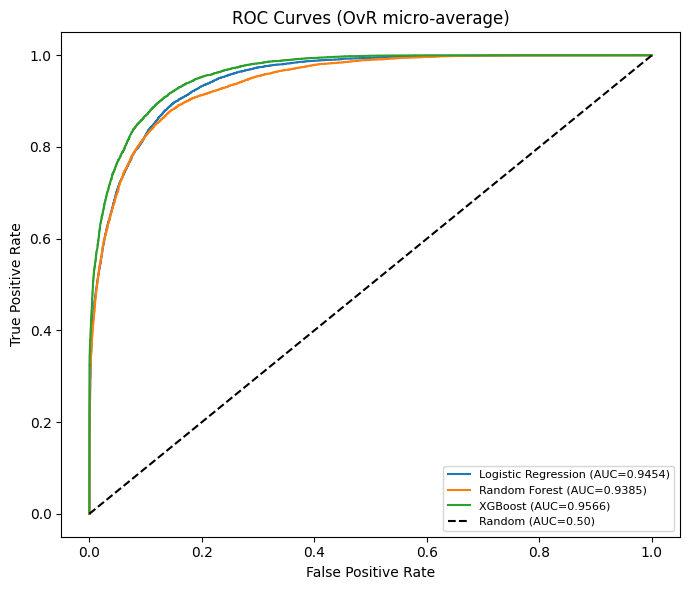

In [38]:
# 3-class ROC: use roc_auc_score with OvR
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

classes = [0, 1, 2]
labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
fig, ax = plt.subplots(figsize=(7, 6))

for name, r in [("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf),
                ("XGBoost", xgb_clf)]:
    y_true_bin = label_binarize(np.array(r["true"]), classes=classes)
    y_score = np.array(r["probs"])
    auc_val = roc_auc_score(np.array(r["true"]), y_score, multi_class='ovr', average='weighted')

    # Plot the OvR micro-average ROC
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (OvR micro-average)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


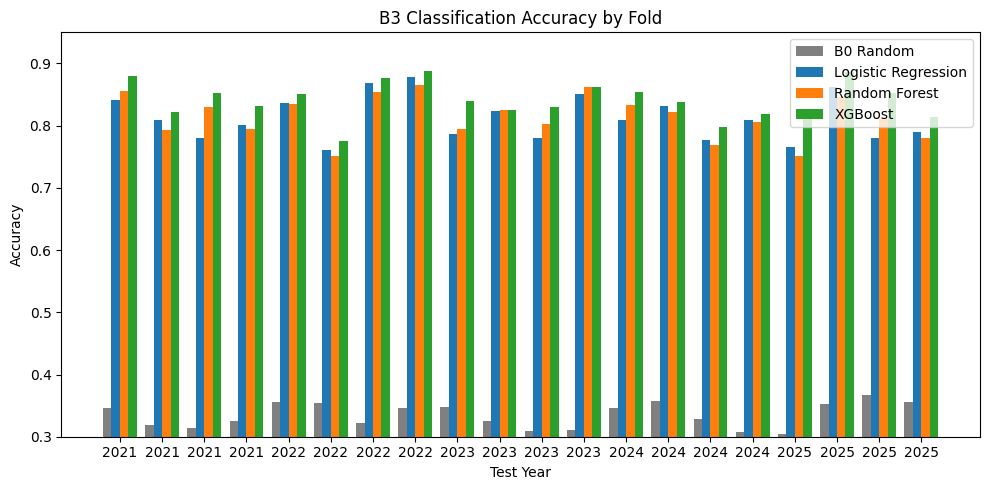

In [39]:
fold_years = [f["test_year"] for f in folds_data]
x     = np.arange(len(fold_years))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width,      b0_clf["fold_acc"],  width, label="B0 Random",          color="gray")
ax.bar(x,              lr_clf["fold_acc"],  width, label="Logistic Regression")
ax.bar(x + width,      rf_clf["fold_acc"],  width, label="Random Forest")
ax.bar(x + 2 * width, xgb_clf["fold_acc"], width, label="XGBoost")

ax.set_xticks(x + width / 2)
ax.set_xticklabels(fold_years)
ax.set_xlabel("Test Year")
ax.set_ylabel("Accuracy")
ax.set_title("B3 Classification Accuracy by Fold")
ax.set_ylim(0.3, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

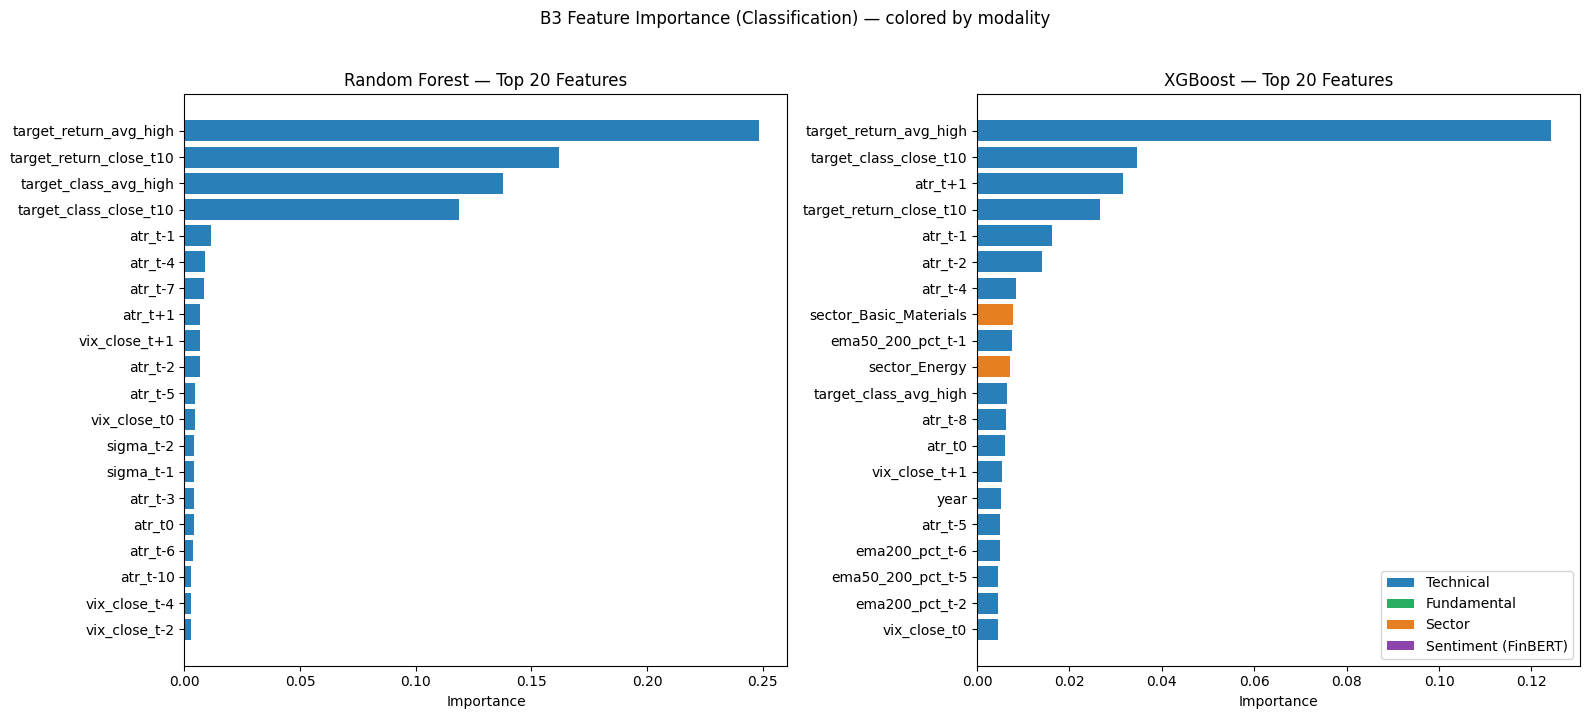

In [40]:
FUND_COLS = {
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin",   "gross_margin_qoq",
    "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin",     "fcf_margin_qoq",
    "roe",            "roe_qoq",
}
SENTIMENT_COLS = {"pos_prob", "neg_prob"}

def feature_color(name):
    if name.startswith("sector_"):  return "#e67e22"  # orange  — sector
    if name in FUND_COLS:           return "#27ae60"  # green   — fundamental
    if name in SENTIMENT_COLS:      return "#8e44ad"  # purple  — sentiment
    return "#2980b9"                                  # blue    — technical

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (label, imp) in zip(axes, [
    ("Random Forest", rf_clf_model.feature_importances_),
    ("XGBoost",       xgb_clf_model.feature_importances_),
]):
    top_idx   = np.argsort(imp)[-20:]
    top_names = np.array(feature_cols)[top_idx]
    top_imp   = imp[top_idx]
    colors    = [feature_color(n) for n in top_names]

    ax.barh(top_names, top_imp, color=colors)
    ax.set_title(f"{label} — Top 20 Features")
    ax.set_xlabel("Importance")

legend_elements = [
    Patch(facecolor="#2980b9", label="Technical"),
    Patch(facecolor="#27ae60", label="Fundamental"),
    Patch(facecolor="#e67e22", label="Sector"),
    Patch(facecolor="#8e44ad", label="Sentiment (FinBERT)"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

plt.suptitle("B3 Feature Importance (Classification) — colored by modality", y=1.02)
plt.tight_layout()
plt.show()

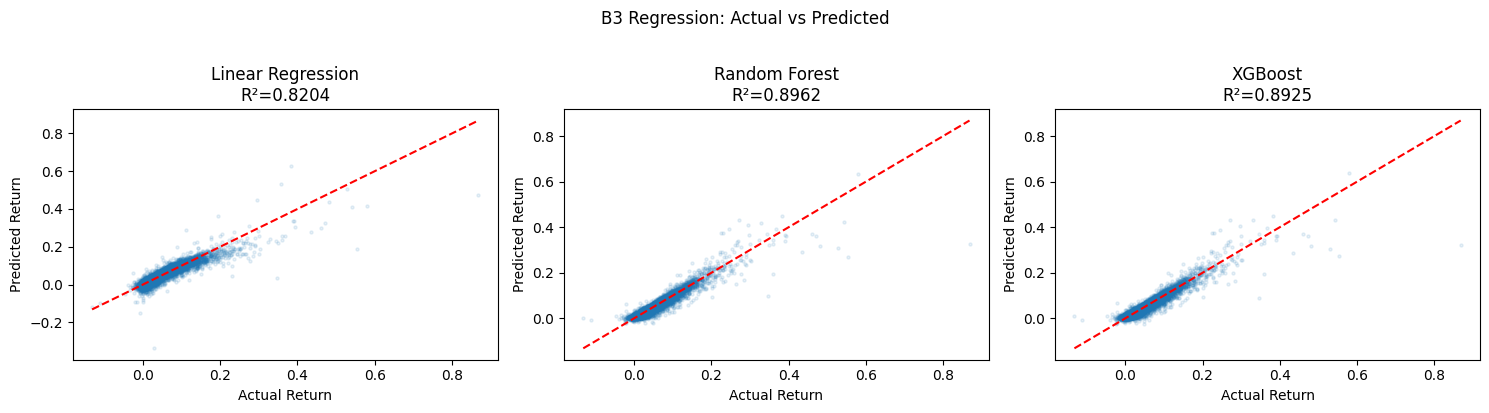

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Linear Regression", linreg),
                                  ("Random Forest",     rf_reg),
                                  ("XGBoost",           xgb_reg)]):
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    ax.scatter(true, preds, alpha=0.1, s=5)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], "r--")
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{name}\nR²={r2_score(true, preds):.4f}")

plt.suptitle("B3 Regression: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

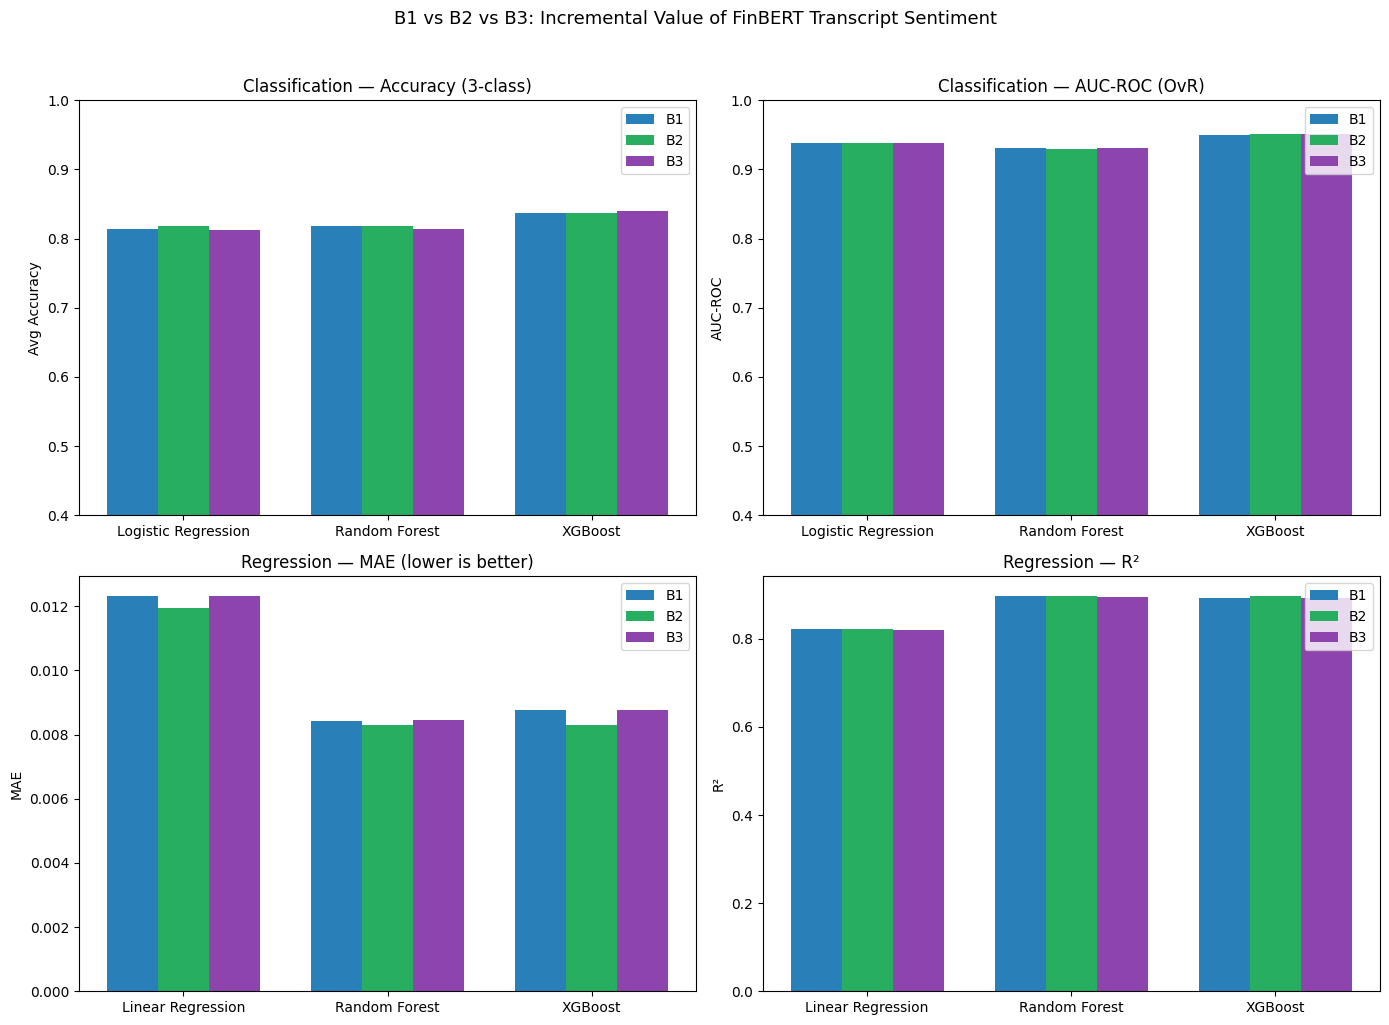

In [42]:
with open("../model_outputs/models/b1_results.pkl", "rb") as f:
    b1 = pickle.load(f)
with open("../model_outputs/models/b2_results.pkl", "rb") as f:
    b2 = pickle.load(f)

b3 = {
    "clf": {"Logistic Regression": lr_clf,  "Random Forest": rf_clf,  "XGBoost": xgb_clf},
    "reg": {"Linear Regression":   linreg,  "Random Forest": rf_reg,  "XGBoost": xgb_reg},
}

clf_models = ["Logistic Regression", "Random Forest", "XGBoost"]
reg_models = ["Linear Regression",   "Random Forest", "XGBoost"]

def clf_da(res, m):  return np.mean(res["clf"][m]["fold_acc"])
def clf_auc(res, m): return roc_auc_score(np.array(res["clf"][m]["true"]),
                                           np.array(res["clf"][m]["probs"]), multi_class='ovr')
def reg_mae(res, m): return np.mean(res["reg"][m]["fold_mae"])
def reg_r2(res, m):  return r2_score(np.array(res["reg"][m]["true"]),
                                      np.array(res["reg"][m]["preds"]))

x     = np.arange(3)
width = 0.25
colors = {"B1": "#2980b9", "B2": "#27ae60", "B3": "#8e44ad"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Classification DA ──────────────────────────────────────────────────────
ax = axes[0, 0]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [clf_da(res, m) for m in clf_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(clf_models)
ax.set_ylabel("Avg Accuracy")
ax.set_title("Classification — Accuracy (3-class)")
ax.set_ylim(0.4, 1); ax.legend()

# ── Classification AUC ─────────────────────────────────────────────────────
ax = axes[0, 1]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [clf_auc(res, m) for m in clf_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(clf_models)
ax.set_ylabel("AUC-ROC")
ax.set_title("Classification — AUC-ROC (OvR)")
ax.set_ylim(0.4, 1); ax.legend()

# ── Regression MAE ─────────────────────────────────────────────────────────
ax = axes[1, 0]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [reg_mae(res, m) for m in reg_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(reg_models)
ax.set_ylabel("MAE")
ax.set_title("Regression — MAE (lower is better)")
ax.legend()

# ── Regression R² ──────────────────────────────────────────────────────────
ax = axes[1, 1]
for i, (label, res) in enumerate([("B1", b1), ("B2", b2), ("B3", b3)]):
    ax.bar(x + (i - 1) * width, [reg_r2(res, m) for m in reg_models],
           width, label=label, color=colors[label])
ax.set_xticks(x); ax.set_xticklabels(reg_models)
ax.set_ylabel("R²")
ax.set_title("Regression — R²")
ax.legend()

plt.suptitle("B1 vs B2 vs B3: Incremental Value of FinBERT Transcript Sentiment",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()